In [169]:
# Imports to extend path to retrieve other .py files
import os
import sys
module_path = os.path.abspath(os.path.join(r'C:\Users\Sleepycornbread\Python Projects\Portfolio Projects\PGA Betting Model'))
if module_path not in sys.path:
    sys.path.append(module_path)

# regular imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# App imports
from app.models.master import Master
from app.db.db_setup import get_db

# SQLalchemy imports
from sqlalchemy.orm import Session
from sqlalchemy import select

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm


In [170]:
# Initializing db session
db = next(get_db())

In [171]:
# Get masters table query
def get_masters_table(db: Session):
    query = select(Master)
    result = db.execute(query)
    return result.scalars().fetchall()

In [172]:
# Getting masters table and adjusting columns
result = get_masters_table(db)
df = pd.DataFrame([vars(row) for row in result])

df.drop('_sa_instance_state', axis=1, inplace=True)

# Creating a key & dropping duplicates
df['key'] = df['year'].astype(str) + '_' + df['player_id'].astype(str) + '_' + df['tournament_name']
df.drop_duplicates(subset='key', inplace=True)
df.drop(columns=['key'], inplace=True)

# Reorder columns 
column_order = ['id', 'year', 'tourney_id', 'tournament_name', 'course_name', 'player_id', 'player_name', 'finish', 'score', 'sg_total', 'sg_ttg', 'sg_ott', 'sg_apr', 'sg_atg', 'sg_putt', 'odds']
df = df[column_order]

# Drop rows with NaN values, excluding 'tourney_id' and 'odds' columns
columns_to_check = [col for col in df.columns if col not in ['tourney_id', 'odds']]
df.dropna(subset=columns_to_check, inplace=True)

df

,id,year,tourney_id,tournament_name,course_name,player_id,player_name,finish,score,sg_total,sg_ttg,sg_ott,sg_apr,sg_atg,sg_putt,odds
0,31775,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",33399,Adam Hadwin,44.0,-1.0,-0.229,-0.068,0.021,-0.335,0.249,-0.160,NaN
1,31776,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",99999,Alexander Noren,52.0,1.0,-0.431,-0.881,-0.426,-0.325,-0.137,0.454,NaN
2,31777,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",34256,Andrew Putnam,23.0,-5.0,1.421,0.639,0.277,-0.034,0.396,0.777,NaN
3,31778,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",24502,Adam Scott,5.0,-10.0,0.956,0.695,0.299,0.008,0.382,0.261,NaN
4,31779,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",46340,Alex Smalley,44.0,-1.0,0.798,0.935,0.347,0.730,-0.141,-0.137,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33973,31751,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,52374,Brandon Wu,99.0,10.0,0.077,-0.035,-0.196,0.001,-0.035,0.308,6969.0
33980,31768,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,32070,Rafael Campos,99.0,11.0,0.878,-0.234,0.840,0.492,-0.234,-0.221,6969.0
33982,31769,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,55708,Hayden Buckley,99.0,12.0,-0.718,-0.080,0.024,-0.602,-0.080,-0.060,6969.0
33983,31722,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,46113,Ryan McCormick,99.0,12.0,0.213,-0.062,-0.051,-0.529,-0.062,0.855,150000.0


In [173]:
# Calculate counts of appearances for each player at each tournament and course
player_tourney_counts = df.groupby(['player_id', 'tournament_name']).size().reset_index(name='num_appearances_tourney')
player_course_counts = df.groupby(['player_id', 'course_name']).size().reset_index(name='num_appearances_course')

# Merge appearance counts with the main DataFrame
df = pd.merge(df, player_tourney_counts, on=['player_id', 'tournament_name'], how='left')
df = pd.merge(df, player_course_counts, on=['player_id', 'course_name'], how='left')

# Calculate average finishes for each player at each course and tournament, excluding the current row
df['player_course_avg_finish'] = df.groupby(['player_id', 'course_name'])['finish'].transform(
    lambda x: round(x.drop_duplicates().mean(), 2) if len(x.drop_duplicates()) > 1 else 50)

df['player_tourney_avg_finish'] = df.groupby(['player_id', 'tournament_name'])['finish'].transform(
    lambda x: round(x.drop_duplicates().mean(), 2) if len(x.drop_duplicates()) > 1 else 50)

# Calculate recency metric: average finishes of the last 3 tournaments for each player, excluding the current row
df['recency_metric'] = df.groupby('player_id')['finish'].transform(
    lambda x: round(x.rolling(window=4, min_periods=1).apply(lambda x: x[:-1].mean()).fillna(50), 2))

# Display the updated DataFrame
df[['player_name', 'player_id', 'tournament_name', 'course_name', 'finish', 
    'player_course_avg_finish', 'player_tourney_avg_finish', 'recency_metric']]

,player_name,player_id,tournament_name,course_name,finish,player_course_avg_finish,player_tourney_avg_finish,recency_metric
0,Adam Hadwin,33399,BMW Championship,"Wilmington Country Club - Wilmington, DE",44.0,50.0,36.50,50.00
1,Alexander Noren,99999,BMW Championship,"Wilmington Country Club - Wilmington, DE",52.0,50.0,34.17,50.00
2,Andrew Putnam,34256,BMW Championship,"Wilmington Country Club - Wilmington, DE",23.0,50.0,27.33,50.00
3,Adam Scott,24502,BMW Championship,"Wilmington Country Club - Wilmington, DE",5.0,50.0,18.80,50.00
4,Alex Smalley,46340,BMW Championship,"Wilmington Country Club - Wilmington, DE",44.0,50.0,50.00,50.00
...,...,...,...,...,...,...,...,...
19602,Brandon Wu,52374,Texas Children's Houston Open,Memorial Park Golf Course,99.0,50.0,50.00,57.00
19603,Rafael Campos,32070,Texas Children's Houston Open,Memorial Park Golf Course,99.0,50.0,50.00,46.00
19604,Hayden Buckley,55708,Texas Children's Houston Open,Memorial Park Golf Course,99.0,50.0,50.00,76.33
19605,Ryan McCormick,46113,Texas Children's Houston Open,Memorial Park Golf Course,99.0,50.0,50.00,99.00


In [174]:
# df = df.loc[df.year == 2024]
df

,id,year,tourney_id,tournament_name,course_name,player_id,player_name,finish,score,sg_total,...,sg_ott,sg_apr,sg_atg,sg_putt,odds,num_appearances_tourney,num_appearances_course,player_course_avg_finish,player_tourney_avg_finish,recency_metric
0,31775,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",33399,Adam Hadwin,44.0,-1.0,-0.229,...,0.021,-0.335,0.249,-0.160,NaN,4,1,50.0,36.50,50.00
1,31776,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",99999,Alexander Noren,52.0,1.0,-0.431,...,-0.426,-0.325,-0.137,0.454,NaN,7,1,50.0,34.17,50.00
2,31777,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",34256,Andrew Putnam,23.0,-5.0,1.421,...,0.277,-0.034,0.396,0.777,NaN,3,1,50.0,27.33,50.00
3,31778,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",24502,Adam Scott,5.0,-10.0,0.956,...,0.299,0.008,0.382,0.261,NaN,5,1,50.0,18.80,50.00
4,31779,2022,R2024028,BMW Championship,"Wilmington Country Club - Wilmington, DE",46340,Alex Smalley,44.0,-1.0,0.798,...,0.347,0.730,-0.141,-0.137,NaN,1,1,50.0,50.00,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19602,31751,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,52374,Brandon Wu,99.0,10.0,0.077,...,-0.196,0.001,-0.035,0.308,6969.0,1,1,50.0,50.00,57.00
19603,31768,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,32070,Rafael Campos,99.0,11.0,0.878,...,0.840,0.492,-0.234,-0.221,6969.0,1,1,50.0,50.00,46.00
19604,31769,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,55708,Hayden Buckley,99.0,12.0,-0.718,...,0.024,-0.602,-0.080,-0.060,6969.0,1,1,50.0,50.00,76.33
19605,31722,2024,R2024020,Texas Children's Houston Open,Memorial Park Golf Course,46113,Ryan McCormick,99.0,12.0,0.213,...,-0.051,-0.529,-0.062,0.855,150000.0,1,1,50.0,50.00,99.00


In [175]:
# Machine Learning - Linear Regression
X = df[['sg_total', 'sg_ttg', 'sg_ott', 'sg_apr', 'sg_atg', 'sg_putt',
        'num_appearances_tourney', 'num_appearances_course',
        'player_course_avg_finish', 'player_tourney_avg_finish', 'recency_metric']]
y = df['finish']

# Splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and training the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting the finish for the test set
y_pred = model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Variable Analysis 

# Adding a constant column to the features (required for statsmodels)
X_train = sm.add_constant(X_train)

# Creating and training the linear regression model using statsmodels
model = sm.OLS(y_train, X_train)
result = model.fit()

# Printing the summary to see the p-values
print(result.summary())

Mean Squared Error: 1009.3924184474592
R^2 Score: 0.22792878079988466
                            OLS Regression Results                            
Dep. Variable:                 finish   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     414.7
Date:                Tue, 02 Apr 2024   Prob (F-statistic):               0.00
Time:                        19:42:51   Log-Likelihood:                -76471.
No. Observations:               15685   AIC:                         1.530e+05
Df Residuals:                   15673   BIC:                         1.531e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

Random Forest Mean Squared Error: 957.5771270780214
Random Forest R^2 Score: 0.2675616276983611
Feature ranking:
1. Feature 'player_tourney_avg_finish' (0.26648992304701735)
2. Feature 'recency_metric' (0.09142721437044547)
3. Feature 'sg_atg' (0.08567641943059529)
4. Feature 'sg_ott' (0.08539890962120543)
5. Feature 'sg_total' (0.08309719702949601)
6. Feature 'sg_apr' (0.082577262261107)
7. Feature 'sg_putt' (0.08250258730705477)
8. Feature 'player_course_avg_finish' (0.08118963741552333)
9. Feature 'sg_ttg' (0.07403971203296288)
10. Feature 'num_appearances_tourney' (0.038440952783588764)
11. Feature 'num_appearances_course' (0.02916018470100385)


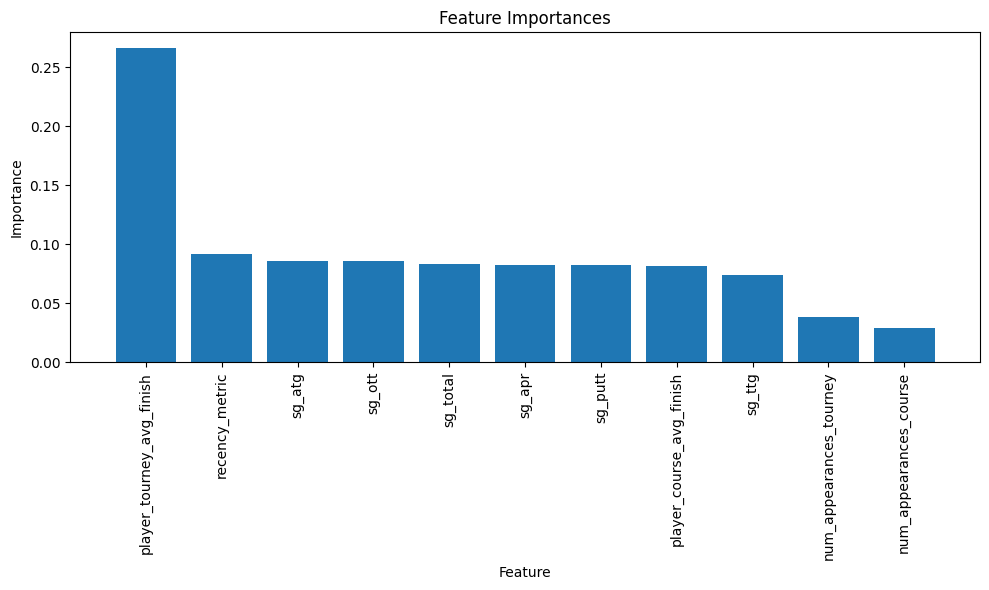

In [176]:
# Lets try random forest

# Splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and training the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predicting the finish for the test set
y_pred_rf = model_rf.predict(X_test)

# Evaluating the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Mean Squared Error:", mse_rf)
print("Random Forest R^2 Score:", r2_rf)

importances = model_rf.feature_importances_
feature_names = X.columns

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X.shape[1]):
    print(f"{f + 1}. Feature '{feature_names[indices[f]]}' ({importances[indices[f]]})")

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()